In [1]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

In [2]:
time_elapsed_df = pd.read_csv('Performance_Analysis//Data//time_elapsed_df.csv', sep = ',')

In [3]:
time_elapsed_df['time_elapsed_ms'] = 1000 * time_elapsed_df['time_elapsed']
time_elapsed_df['words_count (x100)'] = 0.01 * time_elapsed_df['words_count']

In [4]:
time_elapsed_df.describe()

,words_count,time_elapsed,time_elapsed_ms,words_count (x100)
count,5000.000000,5000.000000,5000.000000,5000.000000
mean,170.049000,0.316219,316.219035,1.700490
std,253.365426,0.600122,600.121935,2.533654
min,1.000000,0.004992,4.992485,0.010000
25%,28.000000,0.012846,12.846231,0.280000
50%,92.000000,0.103687,103.687286,0.920000
75%,296.000000,0.447520,447.520256,2.960000
max,3601.000000,12.157738,12157.737970,36.010000


In [17]:
time_elapsed_df.query('words_count < 500').describe()

,words_count,time_elapsed,time_elapsed_ms,words_count (x100)
count,4917.000000,4917.000000,4917.000000,4917.000000
mean,149.117958,0.273365,273.364646,1.491180
std,128.177397,0.377167,377.166949,1.281774
min,1.000000,0.004992,4.992485,0.010000
25%,28.000000,0.012436,12.436390,0.280000
50%,88.000000,0.097776,97.775698,0.880000
75%,296.000000,0.425296,425.295591,2.960000
max,487.000000,3.409619,3409.619093,4.870000


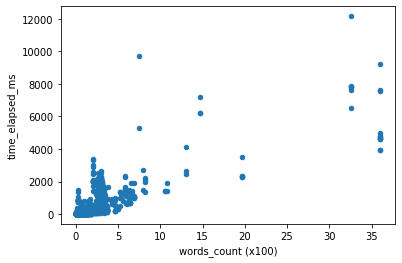

In [5]:
time_elapsed_df.plot.scatter(x = 'words_count (x100)', y = 'time_elapsed_ms')
plt.savefig('OffensiveFilterExecutionTime.pdf')

## Linear Regression over review tokens count

T(w) = 191.47*w + -9.38 score:  0.6534764833061919


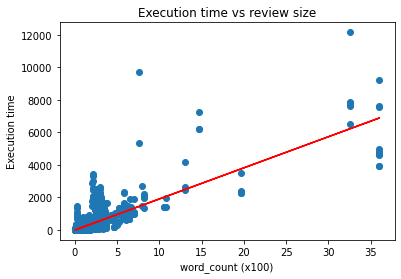

In [19]:
X = time_elapsed_df['words_count (x100)'].values.reshape(-1, 1)
Y = time_elapsed_df.time_elapsed_ms.values.reshape(-1, 1)
reg_1 = LinearRegression()
reg_1.fit(X, Y)
Y_pred = reg_1.predict(X)

score = reg_1.score(X,Y)

plt.scatter(X, Y)
plt.plot(X, Y_pred, color='red')
plt.title('Execution time vs review size')
plt.xlabel('word_count (x100)')
plt.ylabel('Execution time')
#plt.show()
plt.savefig('OffensiveFilterExecutionTime_regression.pdf')

print('T(w) = '+ str(round(reg_1.coef_[0][0],2)) + '*w + '+ str(round(reg_1.intercept_[0],2)), 'score: ', score)